In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import project_dirs as pdir

from sklearn.model_selection import train_test_split

In [17]:
import random

seed=54

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

set_seed(seed)

In [18]:
def stratify_patient_data(
    df,
    patient_col="SampleNumber",
    label_col="Benchmark_Label_7class",
    random_state=seed
):
    """
    Split a WSI-level dataframe into patient-level stratified
    train/validation/test sets.

    Split:
        70% train
        10% validation
        20% test

    Ensures that no patient appears in more than one split.

    Parameters
    ----------
    df : pd.DataFrame
        Input WSI-level dataframe.

    patient_col : str
        Column containing patient IDs.

    label_col : str
        Column containing WSI/class labels.

    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    train_df : pd.DataFrame
    val_df : pd.DataFrame
    test_df : pd.DataFrame
    """

    # ---------------------------------------------------------
    # 1. Create one row per patient
    # ---------------------------------------------------------

    patient_labels = (
        df.groupby(patient_col)[label_col]
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
    )

    # ---------------------------------------------------------
    # 2. First split:
    #    70% train
    #    30% temporary (val + test)
    # ---------------------------------------------------------

    train_patients, temp_patients = train_test_split(
        patient_labels,
        test_size=0.30,
        stratify=patient_labels[label_col],
        random_state=random_state
    )

    # ---------------------------------------------------------
    # 3. Split temporary set:
    #    1/3 validation = 10% total
    #    2/3 test       = 20% total
    # ---------------------------------------------------------

    val_patients, test_patients = train_test_split(
        temp_patients,
        test_size=2/3,
        stratify=temp_patients[label_col],
        random_state=random_state
    )

    # ---------------------------------------------------------
    # 4. Get patient IDs
    # ---------------------------------------------------------

    train_ids = set(train_patients[patient_col])
    val_ids = set(val_patients[patient_col])
    test_ids = set(test_patients[patient_col])

    # ---------------------------------------------------------
    # 5. Map patient IDs back to the original WSI dataframe
    # ---------------------------------------------------------

    train_df = df[df[patient_col].isin(train_ids)].copy()
    val_df = df[df[patient_col].isin(val_ids)].copy()
    test_df = df[df[patient_col].isin(test_ids)].copy()

    # ---------------------------------------------------------
    # 6. Print summary
    # ---------------------------------------------------------

    print("Number of patients:")
    print(f"Train:      {len(train_ids)}")
    print(f"Validation: {len(val_ids)}")
    print(f"Test:       {len(test_ids)}")

    print("\nNumber of WSIs:")
    print(f"Train:      {len(train_df)}")
    print(f"Validation: {len(val_df)}")
    print(f"Test:       {len(test_df)}")

    # ---------------------------------------------------------
    # 7. Verify no patient overlap
    # ---------------------------------------------------------

    assert train_ids.isdisjoint(val_ids)
    assert train_ids.isdisjoint(test_ids)
    assert val_ids.isdisjoint(test_ids)

    print("\n✓ No patient appears in more than one split.")

    return train_df, val_df, test_df

In [19]:
df = pd.read_csv(os.path.join(pdir.CSV_DIR, "CLWD_OneSlide.csv"))

train_df, val_df, test_df = stratify_patient_data(
    df,
    patient_col="SampleNumber",
    label_col="Benchmark_Label_7class",
    random_state=seed
)

Number of patients:
Train:      146
Validation: 21
Test:       42

Number of WSIs:
Train:      151
Validation: 21
Test:       43

✓ No patient appears in more than one split.


In [20]:
def plot_patient_class_distribution(
    train_df,
    val_df,
    test_df,
    patient_col="SampleNumber",
    label_col="Benchmark_Label_7class"
):
    """
    Plot number of unique patients per class for train,
    validation, and test splits.
    """

    splits = {
        "Train": train_df,
        "Validation": val_df,
        "Test": test_df
    }

    # ---------------------------------------------------------
    # Get patient-level class counts
    # ---------------------------------------------------------

    distribution = {}

    for split_name, split_df in splits.items():

        patient_level = (
            split_df
            .drop_duplicates(subset=[patient_col])
            [label_col]
            .value_counts()
        )

        distribution[split_name] = patient_level

    # Combine into one dataframe
    distribution_df = pd.DataFrame(distribution).fillna(0)

    # Sort classes numerically/alphabetically
    distribution_df = distribution_df.sort_index()

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------

    ax = distribution_df.plot(
        kind="bar",
        figsize=(12, 6)
    )

    ax.set_xlabel("Class")
    ax.set_ylabel("Number of patients")
    ax.set_title("Patient distribution by class")
    ax.legend(title="Split")

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Print number of classes
    # ---------------------------------------------------------

    print("\nNumber of classes in each split:")

    for split_name, split_df in splits.items():

        n_classes = split_df[label_col].nunique()

        print(
            f"{split_name}: "
            f"{n_classes} classes"
        )

    return distribution_df

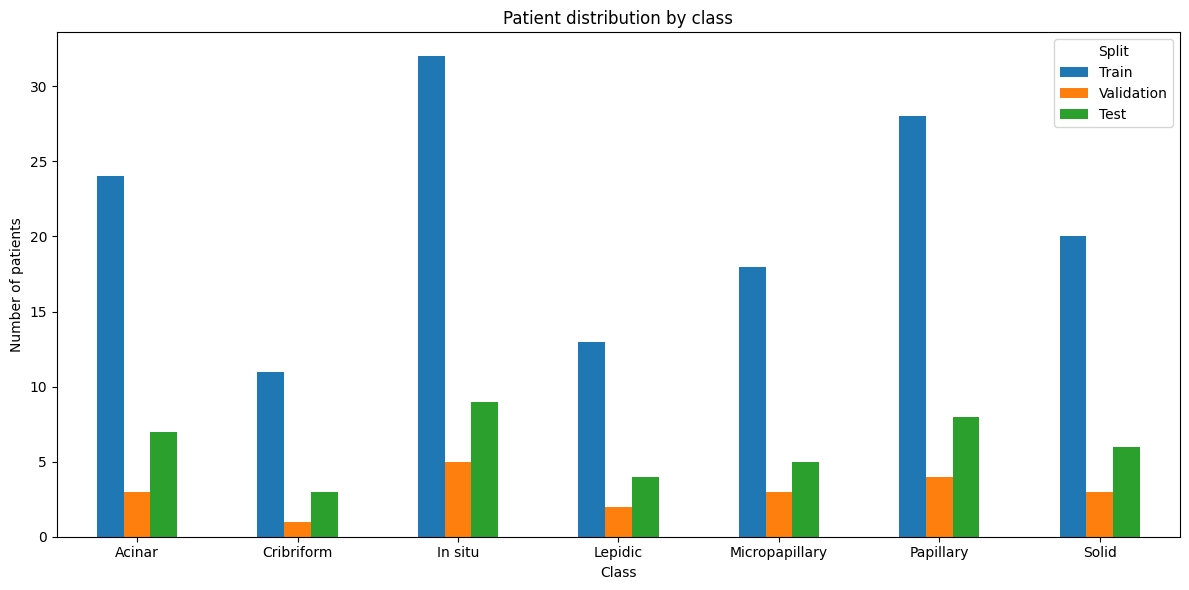


Number of classes in each split:
Train: 7 classes
Validation: 7 classes
Test: 7 classes


In [21]:
distribution = plot_patient_class_distribution(
    train_df,
    val_df,
    test_df
)

In [22]:
fold = "2"
os.makedirs(os.path.join(pdir.CSV_DIR, f"Fold_{fold}"), exist_ok=True)

train_df.to_csv(os.path.join(pdir.CSV_DIR, f"Fold_{fold}", "CLWD_OneSlide-train.csv"), index=False)
val_df.to_csv(os.path.join(pdir.CSV_DIR, f"Fold_{fold}", "CLWD_OneSlide-val.csv"), index=False)
test_df.to_csv(os.path.join(pdir.CSV_DIR, f"Fold_{fold}", "CLWD_OneSlide-test.csv"), index=False)